# Regression using autodiff & gradient descent

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, finite_diff, tensor2d
import numpy as np

In [2]:
A, B = np.random.uniform(0, 5, size=(2,))
N = 50
noise_std = 1.5e-1

xs = np.random.uniform(0, 1, size=(N,))
ys = A * xs + B + np.random.normal(scale=noise_std, size=(N,))

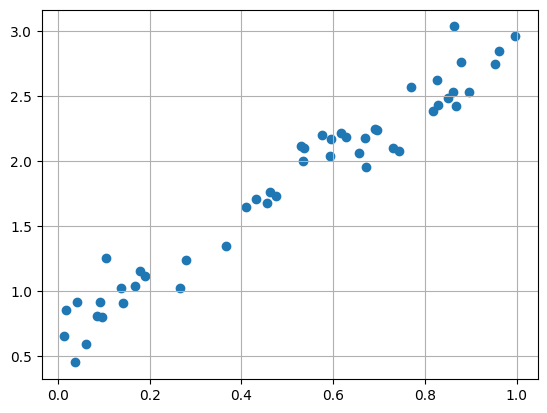

In [3]:
plt.scatter(xs, ys)
plt.grid()

In [4]:
N_iter = 500

x = Node(tensor2d(xs.reshape(-1, 1)))
y = Node(tensor2d(ys.reshape(-1, 1)))
a = Node(tensor2d(np.random.normal(0, 1, size=(1, 1))))
b = Node(tensor2d(np.random.normal(0, 1, size=(1, 1))))

y_p = x @ a + b

# MSE loss
l = ((y_p - y).T @ (y_p - y))

In [5]:
mu = 2.5e-1
losses = []

scale = tensor2d([[1.0 / N]])

for iter in range(N_iter):
    l.zerograd()

    l.forward()
    l.backward()

    a.val -= mu * a.grad @ scale
    b.val -= mu * b.grad @ scale

    # TODO: [] operators
    losses.append(l.val[0,0])

    if iter % 100 == 0:
        print(f"iter {iter}, loss: {losses[-1]:.6f}, "
                f"grad: da={a.grad[0,0]:.6f}, db={b.grad[0,0]:.6f}")
   

iter 0, loss: 90.022755, grad: da=-78.615615, db=-109.061480
iter 100, loss: 1.198395, grad: da=-0.361680, db=0.197661
iter 200, loss: 1.186712, grad: da=-0.008935, db=0.004883
iter 300, loss: 1.186705, grad: da=-0.000221, db=0.000121
iter 400, loss: 1.186705, grad: da=-0.000005, db=0.000003


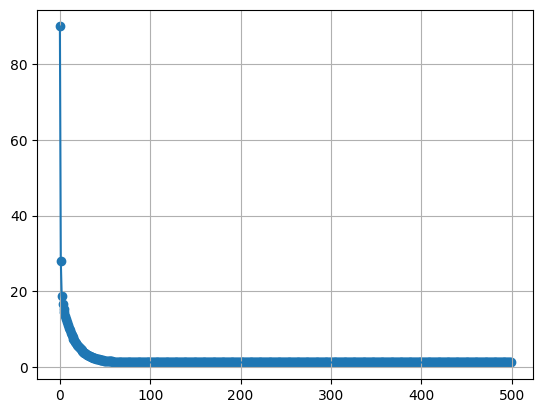

In [6]:
plt.scatter(range(N_iter), losses)
plt.plot(range(N_iter), losses)
plt.grid()

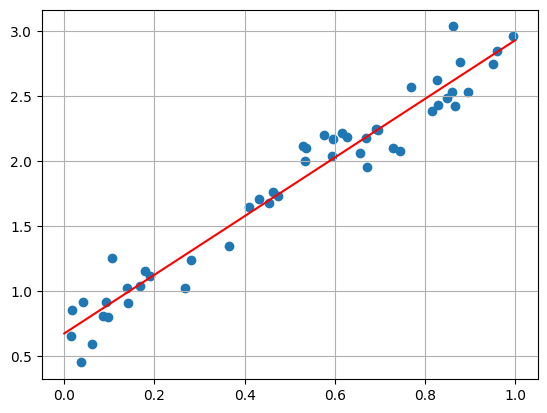

In [7]:
plt.scatter(xs, ys)
plt.plot(
    np.array([0, 1]),
    np.array([b.val[0,0], a.val[0,0] + b.val[0,0]]),
    c='r'
)
plt.grid()

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()
lr.fit(xs.reshape(-1, 1), ys)
print(f"sklearn: a={lr.coef_[0]:.6f}, b={lr.intercept_:.6f}")
print(f"trexdiff: a={a.val[0,0]:.6f}, b={b.val[0,0]:.6f}")


sklearn: a=2.256507, b=0.675473
trexdiff: a=2.256507, b=0.675473


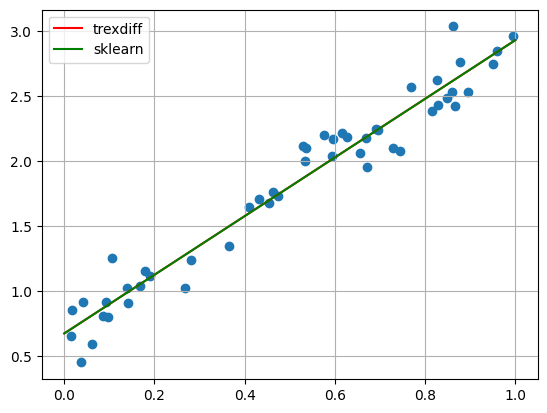

In [10]:
plt.scatter(xs, ys)
plt.plot(
    np.array([0, 1]),
    np.array([b.val[0,0], a.val[0,0] + b.val[0,0]]),
    c='r',
    label='trexdiff'
)
plt.plot(
    np.array([0, 1]),
    np.array([lr.intercept_, lr.coef_[0] + lr.intercept_]),
    c='g',
    label='sklearn'
)
plt.legend()
plt.grid()